# Project Title: Building Machine Learning Model

## Import library

In [2]:
import pandas as pd

## Preparation Data

In [3]:
path = '/home/rizki/projects/data-science/Leukemia Cancer Risk Prediction/project_3_machine_learning_model/data/clean_leukemia_dataset.csv'
df = pd.read_csv(path)

In [4]:
# delete country column
if 'Country' in df.columns:
    df = df.drop(columns=['Country'])
    print("Column Country success deleted")
else:
    print("Column Country not found")

Column Country success deleted


In [5]:
# table column data
df.head()

,Patient_ID,Age,Gender,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,Family_History,...,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status
0,1,52,Male,2698,5.36,262493,12.2,72,Yes,No,...,No,No,No,24.0,No,No,Ethnic_Group_B,Low,Rural,Negative
1,2,15,Female,4857,4.81,277877,11.9,97,Yes,No,...,No,No,No,28.7,No,No,Ethnic_Group_A,Low,Urban,Positive
2,3,72,Male,9614,5.17,319600,13.4,94,No,Yes,...,Yes,No,No,27.7,No,No,Ethnic_Group_B,Low,Urban,Negative
3,4,61,Male,6278,5.41,215200,11.6,50,No,No,...,No,No,No,31.6,No,No,Ethnic_Group_A,Medium,Rural,Negative
4,5,21,Male,8342,4.78,309169,14.3,28,No,No,...,No,No,No,22.3,No,No,Ethnic_Group_B,Low,Rural,Negative


In [6]:
# info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Patient_ID            143194 non-null  int64  
 1   Age                   143194 non-null  int64  
 2   Gender                143194 non-null  object 
 3   WBC_Count             143194 non-null  int64  
 4   RBC_Count             143194 non-null  float64
 5   Platelet_Count        143194 non-null  int64  
 6   Hemoglobin_Level      143194 non-null  float64
 7   Bone_Marrow_Blasts    143194 non-null  int64  
 8   Genetic_Mutation      143194 non-null  object 
 9   Family_History        143194 non-null  object 
 10  Smoking_Status        143194 non-null  object 
 11  Alcohol_Consumption   143194 non-null  object 
 12  Radiation_Exposure    143194 non-null  object 
 13  Infection_History     143194 non-null  object 
 14  BMI                   143194 non-null  float64
 15  

In [7]:
df.describe()

,Patient_ID,Age,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,BMI
count,143194.00000,143194.000000,143194.000000,143194.000000,143194.000000,143194.000000,143194.000000,143194.000000
mean,71597.50000,44.945200,7001.289879,4.998193,249933.012137,13.498334,49.547984,24.990679
std,41336.69156,25.737805,2007.444410,0.500298,49842.308243,1.996714,28.837607,4.999786
min,1.00000,1.000000,-1602.000000,2.940000,46069.000000,4.700000,0.000000,2.800000
25%,35799.25000,23.000000,5644.250000,4.660000,216372.000000,12.100000,25.000000,21.600000
50%,71597.50000,45.000000,7007.000000,5.000000,250248.500000,13.500000,50.000000,25.000000
75%,107395.75000,67.000000,8352.000000,5.340000,283603.500000,14.800000,75.000000,28.300000
max,143194.00000,89.000000,15586.000000,7.150000,460325.000000,22.200000,99.000000,49.100000


In [8]:
# class distribution Leukemia Status
df['Leukemia_Status'].value_counts()

Leukemia_Status
Negative    121797
Positive     21397
Name: count, dtype: int64

## Data Preprocessing

In [9]:
# check missing values
print(df.isnull().sum())

Patient_ID              0
Age                     0
Gender                  0
WBC_Count               0
RBC_Count               0
Platelet_Count          0
Hemoglobin_Level        0
Bone_Marrow_Blasts      0
Genetic_Mutation        0
Family_History          0
Smoking_Status          0
Alcohol_Consumption     0
Radiation_Exposure      0
Infection_History       0
BMI                     0
Chronic_Illness         0
Immune_Disorders        0
Ethnicity               0
Socioeconomic_Status    0
Urban_Rural             0
Leukemia_Status         0
dtype: int64


In [10]:
# encode variable 
print("--- column with data type object (before encoding): ---")
print(df.select_dtypes(include=['object']).columns)

df = pd.get_dummies(df,
                    columns=df.select_dtypes(include=['object']).columns, 
                    drop_first=True)

print("\n--- Data AFTER ENCODING: ---")
df.head()

--- column with data type object (before encoding): ---
Index(['Gender', 'Genetic_Mutation', 'Family_History', 'Smoking_Status',
       'Alcohol_Consumption', 'Radiation_Exposure', 'Infection_History',
       'Chronic_Illness', 'Immune_Disorders', 'Ethnicity',
       'Socioeconomic_Status', 'Urban_Rural', 'Leukemia_Status'],
      dtype='object')

--- Data AFTER ENCODING: ---


,Patient_ID,Age,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,BMI,Gender_Male,Genetic_Mutation_Yes,...,Radiation_Exposure_Yes,Infection_History_Yes,Chronic_Illness_Yes,Immune_Disorders_Yes,Ethnicity_Ethnic_Group_B,Ethnicity_Ethnic_Group_C,Socioeconomic_Status_Low,Socioeconomic_Status_Medium,Urban_Rural_Urban,Leukemia_Status_Positive
0,1,52,2698,5.36,262493,12.2,72,24.0,True,True,...,False,False,False,False,True,False,True,False,False,False
1,2,15,4857,4.81,277877,11.9,97,28.7,False,True,...,False,False,False,False,False,False,True,False,True,True
2,3,72,9614,5.17,319600,13.4,94,27.7,True,False,...,False,False,False,False,True,False,True,False,True,False
3,4,61,6278,5.41,215200,11.6,50,31.6,True,False,...,False,False,False,False,False,False,False,True,False,False
4,5,21,8342,4.78,309169,14.3,28,22.3,True,False,...,False,False,False,False,True,False,True,False,False,False


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Patient_ID                   143194 non-null  int64  
 1   Age                          143194 non-null  int64  
 2   WBC_Count                    143194 non-null  int64  
 3   RBC_Count                    143194 non-null  float64
 4   Platelet_Count               143194 non-null  int64  
 5   Hemoglobin_Level             143194 non-null  float64
 6   Bone_Marrow_Blasts           143194 non-null  int64  
 7   BMI                          143194 non-null  float64
 8   Gender_Male                  143194 non-null  bool   
 9   Genetic_Mutation_Yes         143194 non-null  bool   
 10  Family_History_Yes           143194 non-null  bool   
 11  Smoking_Status_Yes           143194 non-null  bool   
 12  Alcohol_Consumption_Yes      143194 non-null  bool   
 13 

## Split Data for Training and Testing

In [12]:
# import library sckit-learn
from sklearn.model_selection import train_test_split

# set feature (X) and target (y)
X = df.drop(columns=['Leukemia_Status_Positive', 'Patient_ID'])
y = df['Leukemia_Status_Positive']

# split data into training and target sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# print size from training and testing sets
print(f"size X_train: {X_train.shape}")
print(f"size X_test: {X_test.shape}")
print(f"size y_train: {y_train.shape}")
print(f"size y_test: {y_test.shape}")

size X_train: (114555, 21)
size X_test: (28639, 21)
size y_train: (114555,)
size y_test: (28639,)


## Train Model

Check Data Distribution

In [13]:
class_distriibution = y_train.value_counts(normalize=True)
print("--- Distribution class in training set ---\n")
print(class_distriibution)

--- Distribution class in training set ---

Leukemia_Status_Positive
False    0.85057
True     0.14943
Name: proportion, dtype: float64


oversample data manual

In [14]:
#  # concat features and target
# df_train = pd.concat([X_train, y_train], axis=1)

# # split data based target class
# leukemia_positive = df_train[df_train['Leukemia_Status_Positive'] == True] 
# leukemia_negative = df_train[df_train['Leukemia_Status_Positive'] == False] 

# # oversamplit data
# n_negative = len(leukemia_negative)
# n_positive = len(leukemia_positive)
# oversample_factor = int(n_negative / n_positive) -1

# df_oversampled = pd.concat([leukemia_positive] * oversample_factor + [leukemia_positive], ignore_index=True)
# df_oversampled = pd.concat([df_oversampled, leukemia_negative], ignore_index=True)
# df_oversampled = df_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

# print("--- Ukuran Data Training Setelah Manual Oversampling ---")
# print(df_oversampled['Leukemia_Status_Positive'].value_counts())

# x_train_oversampled = df_oversampled.drop(columns=['Leukemia_Status_Positive'])
# y_train_oversampled = df_oversampled['Leukemia_Status_Positive'] 

oversample using SMOTE

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# oversample data training set
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)
print("--- distribution class target training set after oversampling ---")
print(y_train_oversampled.value_counts(normalize=True))

--- distribution class target training set after oversampling ---
Leukemia_Status_Positive
False    0.5
True     0.5
Name: proportion, dtype: float64


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# init model
logreg_model = LogisticRegression(random_state=42, solver='liblinear')
rf_model = RandomForestClassifier(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
xgb_model = XGBClassifier(random_state=42)
lgbm_model = LGBMClassifier(random_state=42)

# train model
logreg_model.fit(X_train_oversampled, y_train_oversampled)
rf_model.fit(X_train_oversampled, y_train_oversampled)
knn_model.fit(X_train_oversampled, y_train_oversampled)
xgb_model.fit(X_train_oversampled, y_train_oversampled)
lgbm_model.fit(X_train_oversampled, y_train_oversampled)

print("Model Logistic Regression success train!")
print("Model Random Forest success train!")
print("Model K-Nearest Neighbors success train!")
print("Model XGBoost success train!")
print("Model LightGBM success train!")

[LightGBM] [Info] Number of positive: 97437, number of negative: 97437
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.079626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1493
[LightGBM] [Info] Number of data points in the train set: 194874, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Model Logistic Regression success train!
Model Random Forest success train!
Model K-Nearest Neighbors success train!
Model XGBoost success train!
Model LightGBM success train!


## Evaluate Model

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# predict model test set
y_pred_logreg = logreg_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgbm = lgbm_model.predict(X_test)

y_pred_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1]
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

In [18]:
# evaluate model Logistic Regression
print("--- evaluate model logistics regression ---\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg)}")
print(f"Precision: {precision_score(y_test, y_pred_logreg, zero_division=0)}")
print(f"Recall: {recall_score(y_test, y_pred_logreg, zero_division=0)}")
print(f"F1 Score: {f1_score(y_test, y_pred_logreg, zero_division=0)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_logreg)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, zero_division=0))

--- evaluate model logistics regression ---

Accuracy: 0.7062397430077866
Precision: 0.14089645587213342
Recall: 0.1895302640803926
F1 Score: 0.16163428001993024
ROC AUC Score: 0.4910104662054844

Confusion Matrix:
[[19415  4945]
 [ 3468   811]]

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.80      0.82     24360
        True       0.14      0.19      0.16      4279

    accuracy                           0.71     28639
   macro avg       0.49      0.49      0.49     28639
weighted avg       0.74      0.71      0.72     28639



In [19]:
# evaluate model random forest
print("--- evaluate model random forest ---\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0)}")
print(f"Recall: {recall_score(y_test, y_pred_rf, zero_division=0)}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf, zero_division=0)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

--- evaluate model random forest ---

Accuracy: 0.7879814239323999
Precision: 0.14801727522575578
Recall: 0.08810469735919607
F1 Score: 0.11046000585994727
ROC AUC Score: 0.49282697106693213

Confusion Matrix:
[[22190  2170]
 [ 3902   377]]

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.91      0.88     24360
        True       0.15      0.09      0.11      4279

    accuracy                           0.79     28639
   macro avg       0.50      0.50      0.50     28639
weighted avg       0.75      0.79      0.76     28639



In [20]:
# # evaluate model k-nearest neighbors
# print("--- evaluate model knn ---\n")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)}")
# print(f"Precision: {precision_score(y_test, y_pred_knn, zero_division=0)}")
# print(f"Recall: {recall_score(y_test, y_pred_knn)}")
# print(f"F1 Score: {f1_score(y_test, y_pred_knn)}")
# print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_knn)}")
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_knn))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_knn))

In [21]:
# evaluate model xgboost
print("--- evaluate model xgboost ---\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Precision: {precision_score(y_test, y_pred_xgb)}")
print(f"Recall: {recall_score(y_test, y_pred_xgb)}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

--- evaluate model xgboost ---

Accuracy: 0.8087922064317888
Precision: 0.15304347826086956
Recall: 0.061696658097686374
F1 Score: 0.08794137241838774
ROC AUC Score: 0.49229526641546856

Confusion Matrix:
[[22899  1461]
 [ 4015   264]]

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.94      0.89     24360
        True       0.15      0.06      0.09      4279

    accuracy                           0.81     28639
   macro avg       0.50      0.50      0.49     28639
weighted avg       0.75      0.81      0.77     28639



In [22]:
# evaluate model lightgbm
print("--- evaluate model lightgbm ---\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm)}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm)}")
print(f"Recall: {recall_score(y_test, y_pred_lgbm)}")
print(f"F1 Score: {f1_score(y_test, y_pred_lgbm)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lgbm)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

--- evaluate model lightgbm ---

Accuracy: 0.8158455253325885
Precision: 0.14641080312722105
Recall: 0.048142089273194674
F1 Score: 0.07245867041857193
ROC AUC Score: 0.4890577853579804

Confusion Matrix:
[[23159  1201]
 [ 4073   206]]

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.95      0.90     24360
        True       0.15      0.05      0.07      4279

    accuracy                           0.82     28639
   macro avg       0.50      0.50      0.49     28639
weighted avg       0.75      0.82      0.77     28639



Feature selection

In [23]:
# from sklearn.feature_selection import SelectKBest, f_classif
# from sklearn.model_selection import StratifiedKFold
# import numpy as np

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# k_values = range(1, X_train_oversampled.shape[1] + 1)
# mean_recalls = []

# for k in k_values:
#     recalls = []
#     selector = SelectKBest(score_func=f_classif, k=k)
#     X_selected = selector.fit_transform(X, y)

#     for train_index, val_index in skf.split(X_selected, y):
#         X_train_fold, X_val_fold = X_selected[train_index], X_selected[val_index]
#         y_train_fold, y_val_fold = y[train_index], y[val_index]

#         knn = KNeighborsClassifier(n_neighbors=5)
#         knn.fit(X_train_fold, y_train_fold)
#         y_pred_fold = knn.predict(X_val_fold)
#         recalls.append(recall_score(y_val_fold, y_pred_fold))

#     mean_recalls.append(np.mean(recalls))
    
# best_k = k_values[np.argmax(mean_recalls)]
# print(f"Nilai k terbaik berdasarkan cross-validation: {best_k}")

In [24]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)

selector.fit(X_train_oversampled, y_train_oversampled)

X_train_selected = selector.transform(X_train_oversampled)
X_test_selected = selector.transform(X_test)

knn_selected = KNeighborsClassifier(n_neighbors=5)
knn_selected.fit(X_train_selected, y_train_oversampled)

y_pred_selected_knn = knn_selected.predict(X_test_selected)
y_pred_proba_selected_knn = knn_selected.predict_proba(X_test_selected)[:, 1]

In [25]:
print("--- evaluate knn model with feature selection ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_selected_knn)}")
print(f"Precision: {precision_score(y_test, y_pred_selected_knn)}")
print(f"Recall: {recall_score(y_test, y_pred_selected_knn)}")
print(f"F1-Score: {f1_score(y_test, y_pred_selected_knn)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_selected_knn)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_selected_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_selected_knn))

--- evaluate knn model with feature selection ---
Accuracy: 0.5856698907084744
Precision: 0.14969064548896482
Recall: 0.378826828698294
F1-Score: 0.21458829759068043
ROC AUC Score: 0.5006508664340417

Confusion Matrix:
[[15152  9208]
 [ 2658  1621]]

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.62      0.72     24360
        True       0.15      0.38      0.21      4279

    accuracy                           0.59     28639
   macro avg       0.50      0.50      0.47     28639
weighted avg       0.75      0.59      0.64     28639



Ensemble model

In [28]:
from sklearn.ensemble import VotingClassifier

estimators = [
    ('logreg', LogisticRegression(random_state=42, solver='liblinear')),
    ('rf', RandomForestClassifier(random_state=42)),
    ('knn', knn_selected),
    ('xgb', xgb_model),
    ('lgbm', LGBMClassifier(random_state=42))
]

# init votingClassifier
voting_clf = VotingClassifier(estimators=estimators, voting='soft')

# fit ensemble model
voting_clf.fit(X_train_oversampled, y_train_oversampled)

y_pred_ensemble = voting_clf.predict(X_test)

[LightGBM] [Info] Number of positive: 97437, number of negative: 97437
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.315157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1493
[LightGBM] [Info] Number of data points in the train set: 194874, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [29]:
print("--- Evaluasi Model Ensemble (VotingClassifier) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ensemble)}")
print(f"Precision: {precision_score(y_test, y_pred_ensemble)}")
print(f"Recall: {recall_score(y_test, y_pred_ensemble)}")
print(f"F1-Score: {f1_score(y_test, y_pred_ensemble)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, voting_clf.predict_proba(X_test)[:, 1])}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ensemble))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble))

--- Evaluasi Model Ensemble (VotingClassifier) ---
Accuracy: 0.7985614022835993
Precision: 0.14891611687087652
Recall: 0.07384903014723067
F1-Score: 0.09873457272301203


ROC AUC Score: 0.49281564105604525

Confusion Matrix:
[[22554  1806]
 [ 3963   316]]

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.93      0.89     24360
        True       0.15      0.07      0.10      4279

    accuracy                           0.80     28639
   macro avg       0.50      0.50      0.49     28639
weighted avg       0.75      0.80      0.77     28639



## Visualization

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

## Distribution data

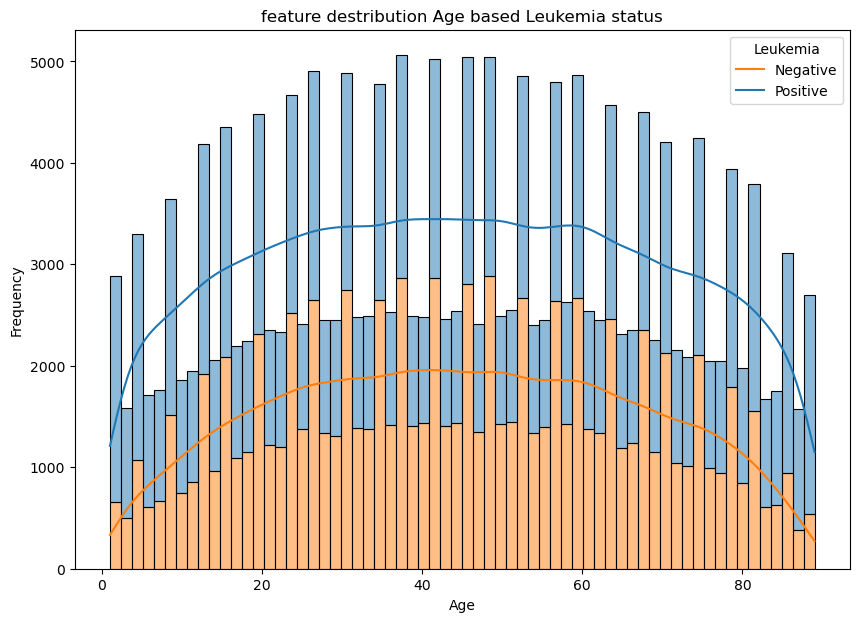

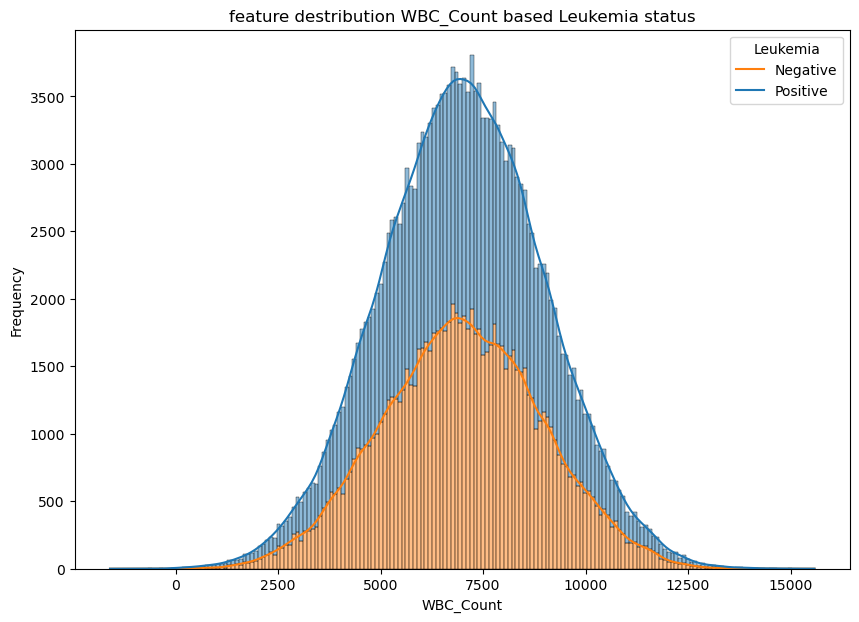

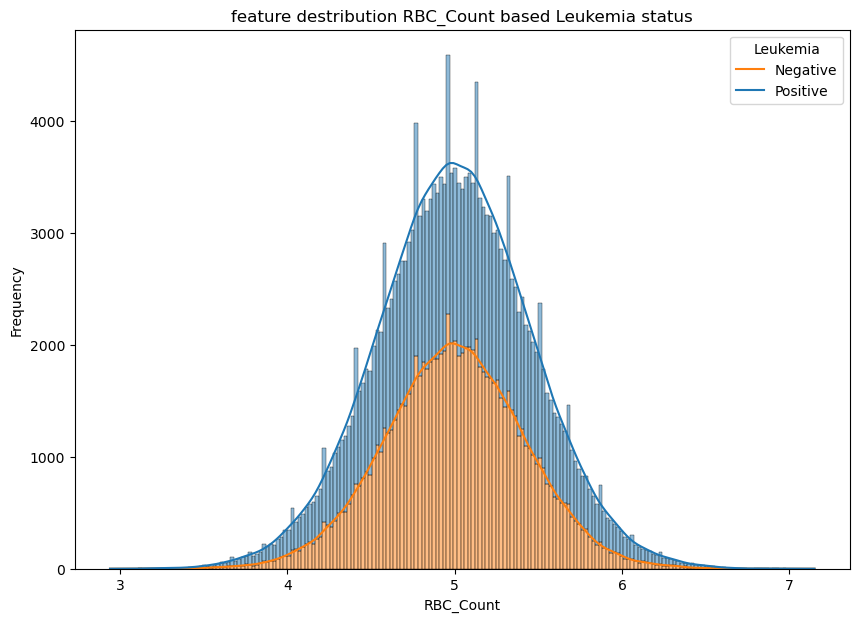

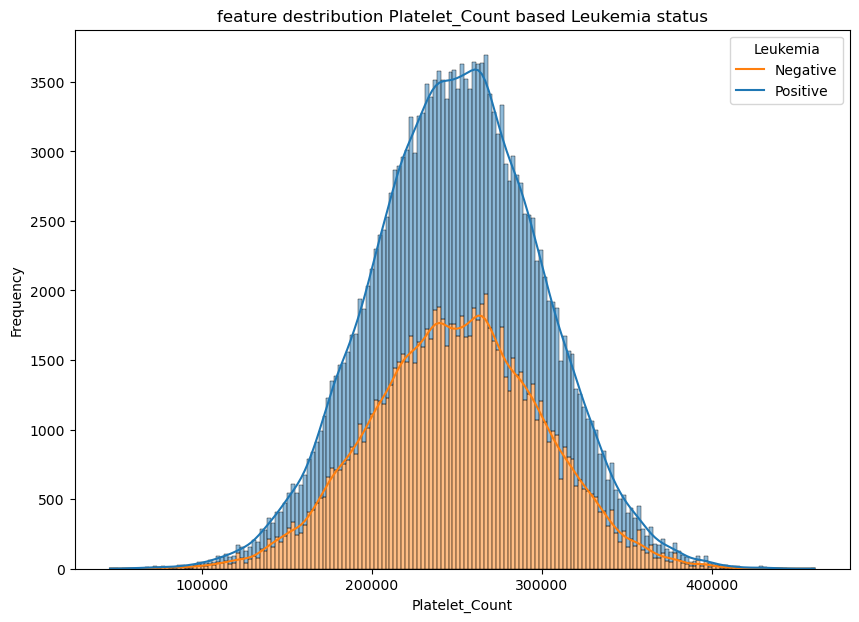

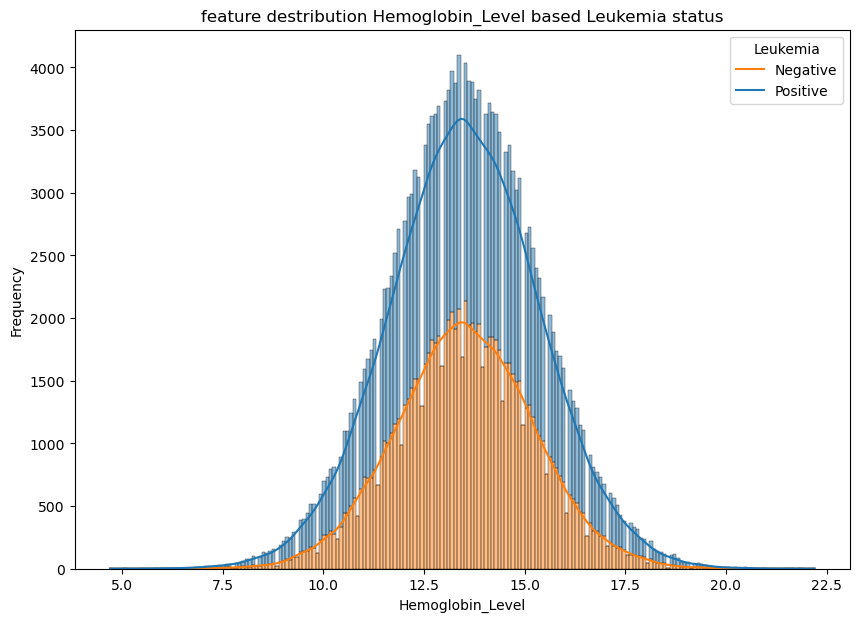

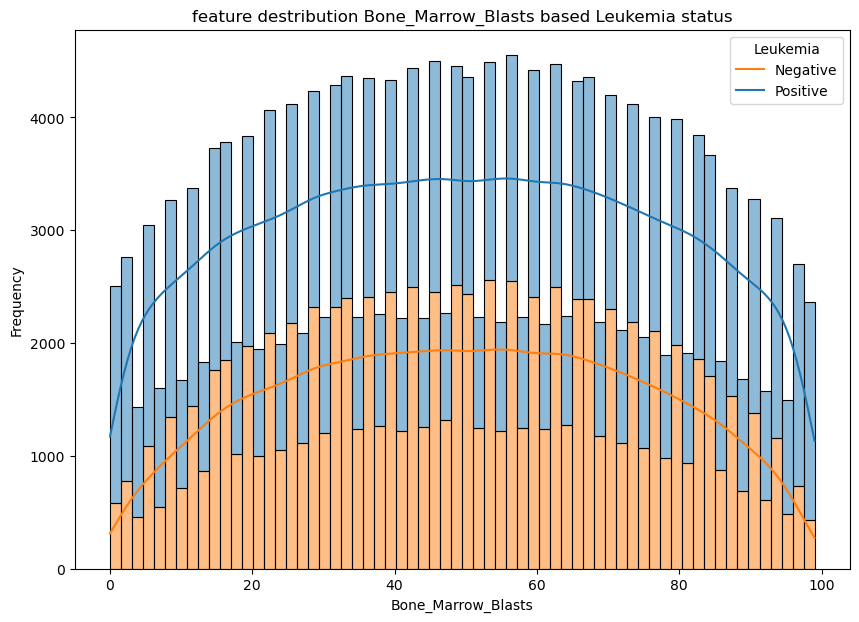

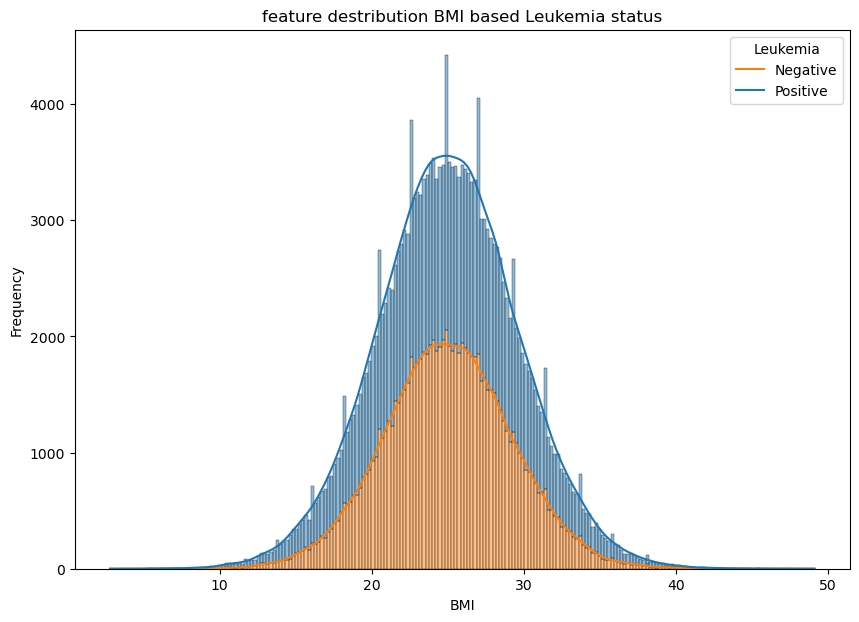

In [36]:
train_df_oversampled = pd.concat([X_train_oversampled, y_train_oversampled], axis=1)
train_df_oversampled.rename(columns={train_df_oversampled.columns[-1]: 'Leukemia'}, inplace=True)

features_to_visualize = ['Age', 'WBC_Count', 'RBC_Count', 'Platelet_Count', 'Hemoglobin_Level',	'Bone_Marrow_Blasts', 'BMI']

for feature in features_to_visualize:
    plt.figure(figsize=(10, 7))
    sns.histplot(data=train_df_oversampled, x=feature, hue='Leukemia', kde=True, multiple='stack')
    plt.title(f'feature destribution {feature} based Leukemia status')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend(title='Leukemia', labels=['Negative', 'Positive'])
    plt.show()